In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

import timeit

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

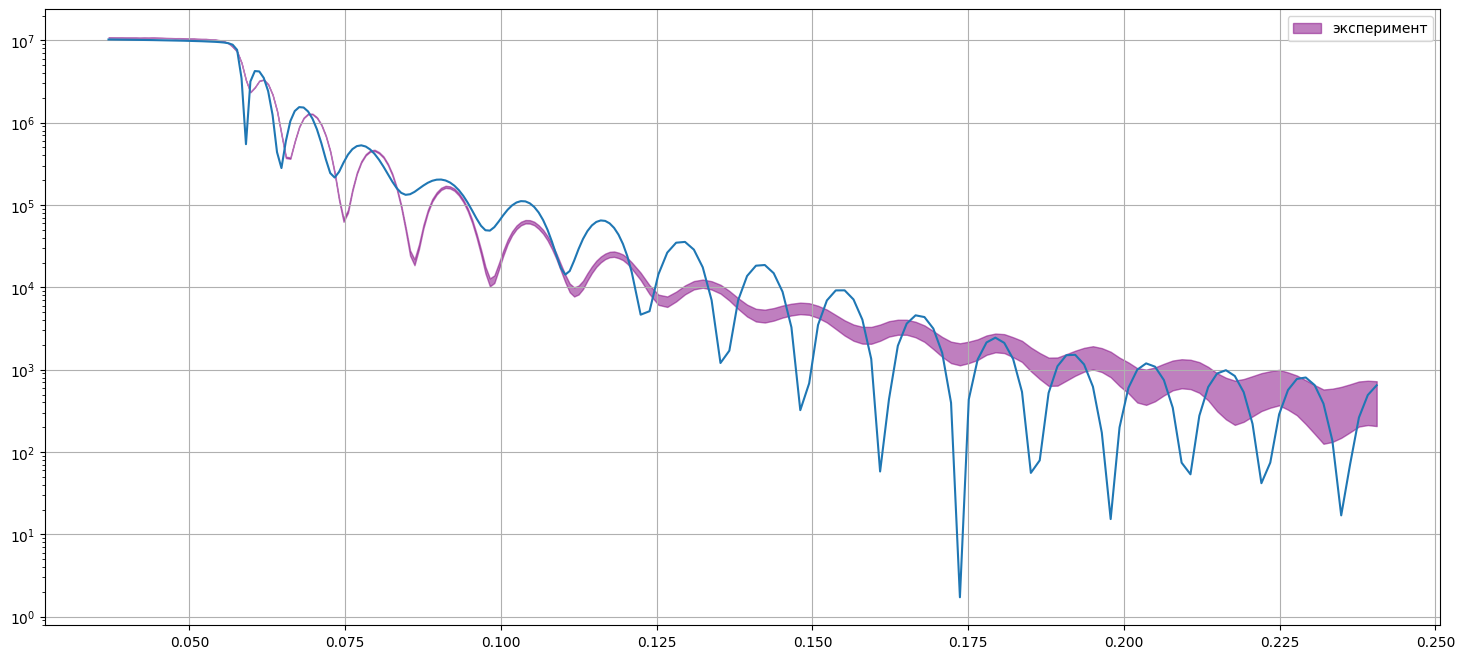

In [2]:
q = torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/1.5406
r_mod, r_mod_conv= reflectometry(q, matr, initial_sigma1, initial_sigma2, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-10, r-delta_r, r+delta_r, color='purple', alpha=0.5, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10, (I0*r_mod_conv).tolist())
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

r = torch.tensor(r/I0.cpu().detach().numpy())

In [4]:
from objective_function import *

loss_function = Comparator(q, r, delta_r, I0)

objective_function = varbounds(all_bounds, loss_function.compare)
objective_function_weightless = varbounds(all_bounds, loss_function.compare_weightless)
objective_function_pearson = varbounds(all_bounds, loss_function.pearson)

In [5]:
objective_function_weightless.objective_function(initial_d, torch.complex(initial_r_rho, initial_i_rho), initial_delta_q, initial_sigma1, initial_sigma2, I0, Ibkg)

tensor(306.0204, dtype=torch.float64, grad_fn=<SumBackward0>)

In [6]:
objective_function.objective_function(initial_d, torch.complex(initial_r_rho, initial_i_rho), initial_delta_q, initial_sigma1, initial_sigma2, I0, Ibkg)

tensor(0.2688, dtype=torch.float64, grad_fn=<SumBackward0>)

In [7]:
objective_function_pearson.objective_function(initial_d, torch.complex(initial_r_rho, initial_i_rho), initial_delta_q, initial_sigma1, initial_sigma2, I0, Ibkg)

tensor(0.0120, dtype=torch.float64, grad_fn=<SumBackward0>)

In [8]:
N = q.shape[0]
n_split = N // 3  

q1 = q[:n_split]             
q2 = q[:2*n_split]
q3 = q[:3*n_split:]

r1 = r[:n_split]             
r2 = r[:2*n_split]
r3 = r[:3*n_split]

relative_loss:   1.0 
 structure: 
 tensor([[399.7800+0.0000j,  64.5150-1.3533j,  60.2200+0.0000j],
        [100.0000+0.0000j,  19.9610-0.8702j,  80.2199+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 6.0238e-04+0.0000j, -2.0092e-03-0.0009j, -3.6963e-04+0.0000j],
        [ 0.0000e+00+0.0000j,  4.4842e-04+0.0003j, -1.5437e-05+0.0000j]]) 
 delta_q:   tensor(-7117.4790, requires_grad=True) 
 grad_delta_q:   tensor(8.9345e-10) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.21999999999999997 
 iteration:   1 



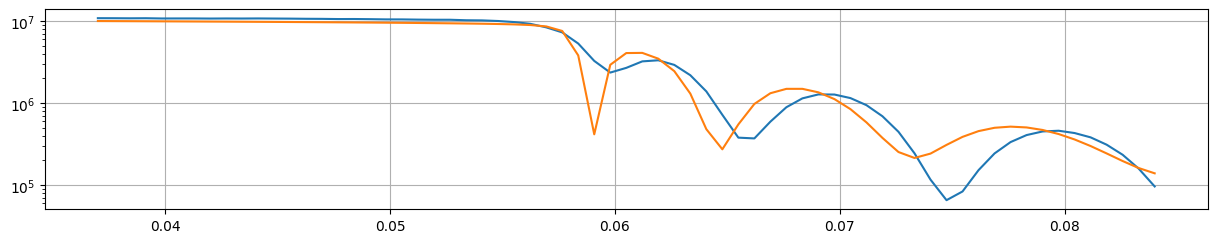

relative_loss:   0.35467183048194434 
 structure: 
 tensor([[388.0206+0.0000j,  65.5230-1.3745j,  81.6279+0.0000j],
        [100.0000+0.0000j,  17.0700-0.8702j,  86.4901+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[-1.8344e-04+0.0000j,  6.6000e-04-0.0003j,  2.2349e-05+0.0000j],
        [ 0.0000e+00+0.0000j,  9.3419e-06-0.0021j, -2.6035e-05+0.0000j]]) 
 delta_q:   tensor(-20300.5645, requires_grad=True) 
 grad_delta_q:   tensor(-4.1734e-10) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.19488532379007995 
 iteration:   134 



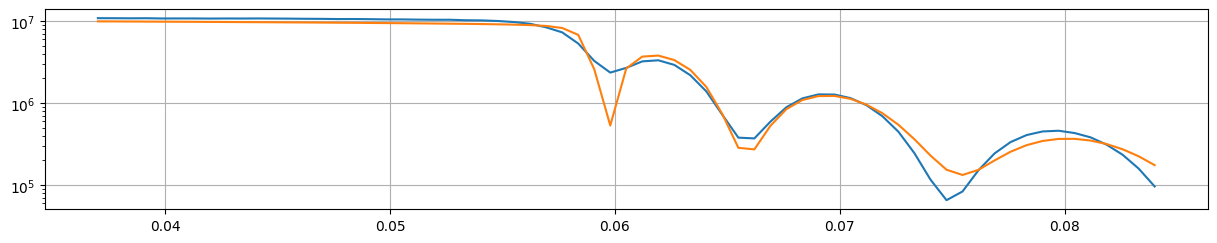

relative_loss:   0.3237769216931921 
 structure: 
 tensor([[397.6247+0.0000j,  65.3243-1.3703j,  85.6399+0.0000j],
        [100.0000+0.0000j,  17.3269-0.8702j,  91.0318+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 8.4393e-05+0.0000j, -1.2243e-03-0.0011j, -2.0140e-05+0.0000j],
        [ 0.0000e+00+0.0000j, -2.0118e-05-0.0024j,  3.7444e-05+0.0000j]]) 
 delta_q:   tensor(115602.2734, requires_grad=True) 
 grad_delta_q:   tensor(3.3513e-10) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.16918492563722284 
 iteration:   267 



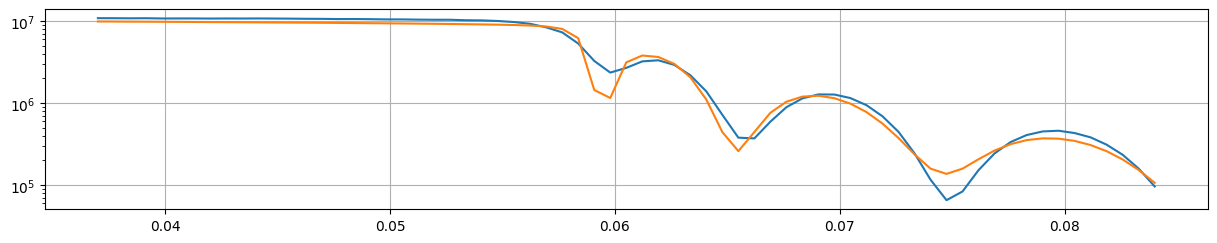

relative_loss:   0.30694584487854404 
 structure: 
 tensor([[399.3880+0.0000j,  65.7367-1.3789j,  88.3064+0.0000j],
        [100.0000+0.0000j,  18.1662-0.8702j,  90.5632+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 3.9658e-05+0.0000j, -3.8345e-04-0.0008j,  2.6431e-06+0.0000j],
        [ 0.0000e+00+0.0000j, -3.1401e-05-0.0022j,  1.6336e-05+0.0000j]]) 
 delta_q:   tensor(206485.0312, requires_grad=True) 
 grad_delta_q:   tensor(-2.2161e-12) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.14687375378612075 
 iteration:   400 



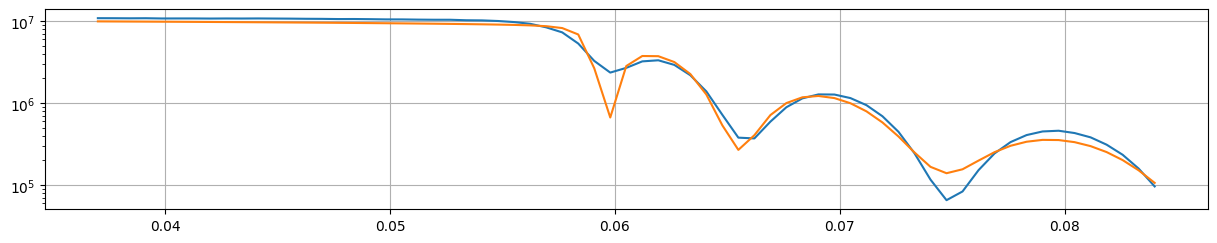

In [9]:
from optimizer import *
ans_d, ans_r_rho, ans_i_rho, ans_delta_q, ans_I, ans_Ibkg, loss, rel_losses1 = adamw(q1, initial_delta_q, r1, objective_function_pearson.objective_function, initial_sigma1, initial_sigma2,
                                                                      initial_d, initial_r_rho, initial_i_rho, I0, Ibkg, 
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.006, max_iter = 400, k=4)


relative_loss:   1.0 
 structure: 
 tensor([[399.3280+0.0000j,  65.7667-1.3796j,  88.2466+0.0000j],
        [100.0000+0.0000j,  18.1962-0.8702j,  90.5033+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 3.5059e-05+0.0000j, -3.0957e-04-0.0008j,  4.6982e-06+0.0000j],
        [ 0.0000e+00+0.0000j, -3.5080e-05-0.0022j,  1.4700e-05+0.0000j]]) 
 delta_q:   tensor(206561.2344, requires_grad=True) 
 grad_delta_q:   tensor(-3.1855e-11) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.06 
 iteration:   1 



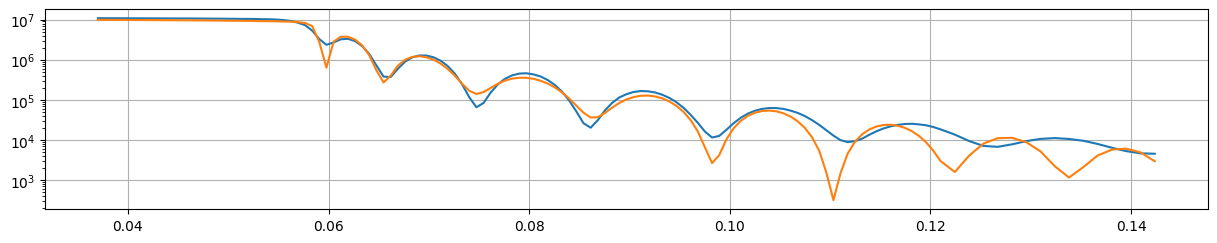

relative_loss:   0.9748020806711102 
 structure: 
 tensor([[397.8329+0.0000j,  65.6828-1.3778j,  86.5981+0.0000j],
        [100.0000+0.0000j,  18.2878-0.8702j,  87.2992+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 1.6850e-05+0.0000j, -2.0096e-04-0.0006j, -1.7528e-06+0.0000j],
        [ 0.0000e+00+0.0000j, -3.4891e-06-0.0020j,  6.2435e-06+0.0000j]]) 
 delta_q:   tensor(247641.3438, requires_grad=True) 
 grad_delta_q:   tensor(-5.4039e-11) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.05315054285183999 
 iteration:   125 



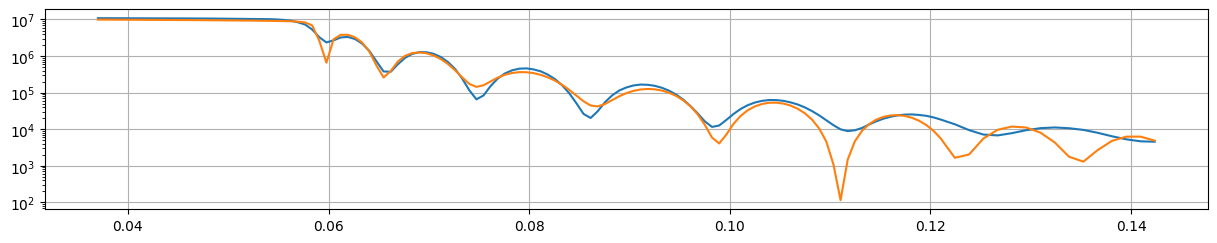

relative_loss:   0.9691872245087779 
 structure: 
 tensor([[396.9904+0.0000j,  65.6562-1.3772j,  86.4024+0.0000j],
        [100.0000+0.0000j,  18.2981-0.8702j,  86.3513+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 2.5963e-06+0.0000j, -1.4699e-04-0.0006j,  1.1517e-06+0.0000j],
        [ 0.0000e+00+0.0000j,  2.6354e-07-0.0019j,  3.6321e-06+0.0000j]]) 
 delta_q:   tensor(280607.4375, requires_grad=True) 
 grad_delta_q:   tensor(-7.2632e-11) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.047083003424087985 
 iteration:   249 



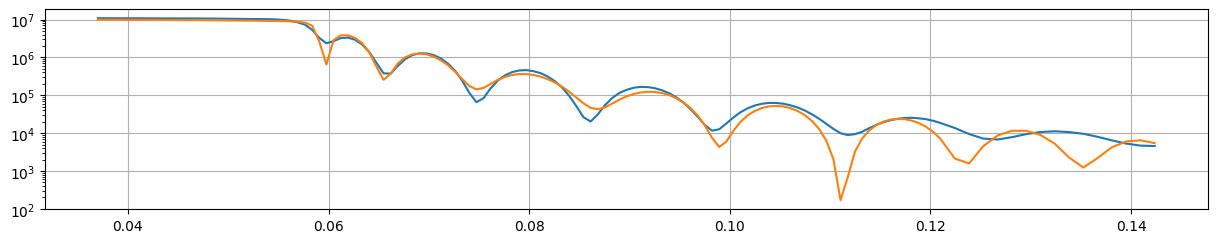

relative_loss:   0.9893634374759587 
 structure: 
 tensor([[397.2953+0.0000j,  65.7923-1.3801j,  86.2477+0.0000j],
        [100.0000+0.0000j,  18.2213-0.8702j,  86.2607+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[-1.0947e-05+0.0000j,  2.0735e-04-0.0005j,  4.3599e-06+0.0000j],
        [ 0.0000e+00+0.0000j, -1.1687e-05-0.0019j, -5.7408e-06+0.0000j]]) 
 delta_q:   tensor(307592.0625, requires_grad=True) 
 grad_delta_q:   tensor(-2.1050e-10) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.04170811985142196 
 iteration:   373 



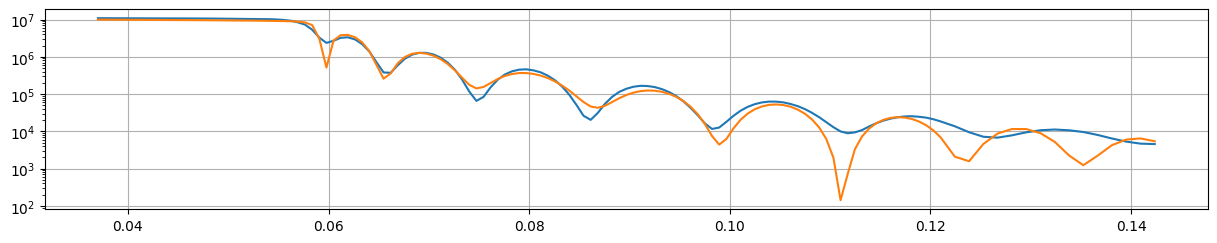

relative_loss:   0.9712131155111341 
 structure: 
 tensor([[397.3387+0.0000j,  65.6784-1.3777j,  86.2909+0.0000j],
        [100.0000+0.0000j,  18.5582-0.8702j,  86.6727+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 1.1811e-05+0.0000j, -2.0051e-04-0.0006j, -5.3688e-06+0.0000j],
        [ 0.0000e+00+0.0000j,  1.3148e-05-0.0019j,  4.8749e-06+0.0000j]]) 
 delta_q:   tensor(333061.4062, requires_grad=True) 
 grad_delta_q:   tensor(-5.0488e-11) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.036946820190544696 
 iteration:   497 



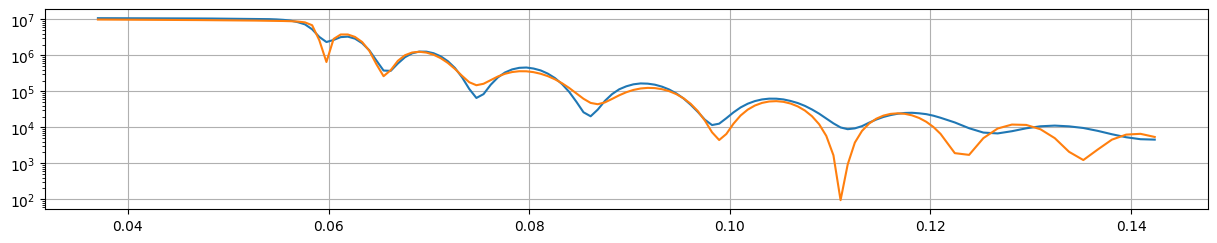

In [10]:
ans_d, ans_r_rho, ans_i_rho, ans_delta_q, ans_I, ans_Ibkg, loss, rel_losses2 = adamw(q2, ans_delta_q, r2, objective_function_pearson.objective_function,
                                                                      initial_sigma1, initial_sigma2,
                                                                      ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, 
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.002, max_iter = 800, k=5)

relative_loss:   1.0 
 structure: 
 tensor([[397.4605+0.0000j,  65.7382-1.3790j,  86.4172+0.0000j],
        [100.0000+0.0000j,  18.4940-0.8702j,  86.7998+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[-1.0541+0.0000j, -1.5005-3.3755j, -0.4578+0.0000j],
        [ 0.0000+0.0000j,  4.5421+0.9013j, -0.5787+0.0000j]]) 
 delta_q:   tensor(380779.9688, requires_grad=True) 
 grad_delta_q:   tensor(-5.6225e-07) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.12 
 iteration:   1 



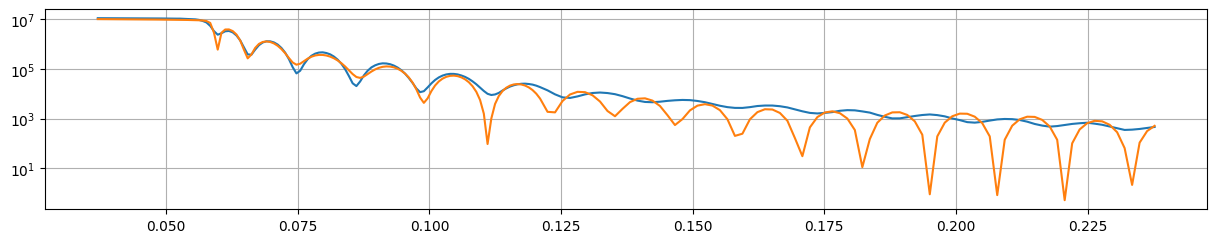

relative_loss:   0.8751306336128871 
 structure: 
 tensor([[404.4861+0.0000j,  66.4100-1.3931j,  87.7821+0.0000j],
        [100.0000+0.0000j,  17.0700-0.8702j,  81.1872+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 0.0074+0.0000j, -1.2168-1.8417j, -0.0537+0.0000j],
        [ 0.0000+0.0000j,  0.8169+1.0228j,  0.0091+0.0000j]]) 
 delta_q:   tensor(-1094038.2500, requires_grad=True) 
 grad_delta_q:   tensor(8.4823e-08) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.08862829231744844 
 iteration:   300 



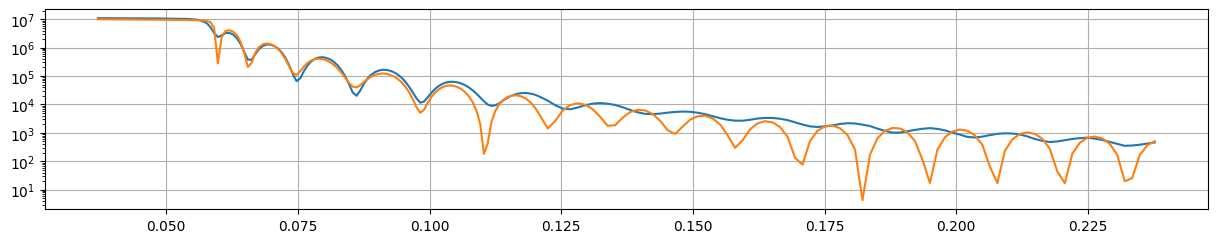

relative_loss:   0.8742070081988643 
 structure: 
 tensor([[405.3582+0.0000j,  66.4100-1.3931j,  88.1816+0.0000j],
        [100.0000+0.0000j,  17.0700-0.8702j,  80.6544+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 0.0072+0.0000j, -0.9450-1.5934j,  0.0030+0.0000j],
        [ 0.0000+0.0000j,  0.7618+1.0687j, -0.0076+0.0000j]]) 
 delta_q:   tensor(-1790171.2500, requires_grad=True) 
 grad_delta_q:   tensor(1.7502e-08) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.06679399829172697 
 iteration:   599 



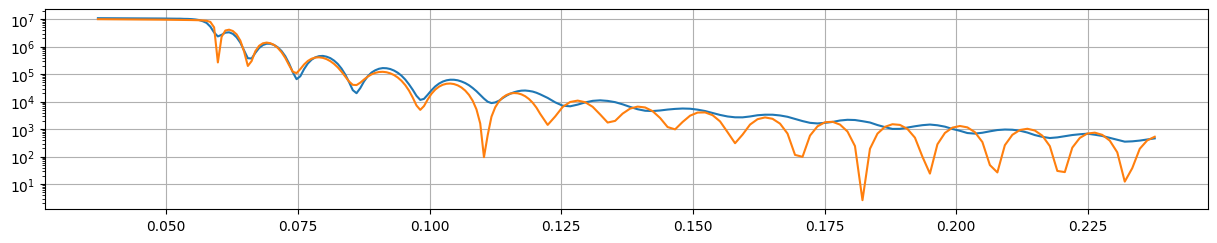

relative_loss:   0.874184225143675 
 structure: 
 tensor([[405.3373+0.0000j,  66.4100-1.3931j,  88.1573+0.0000j],
        [100.0000+0.0000j,  17.0700-0.8702j,  80.7683+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[-1.0315e-03+0.0000j, -9.0991e-01-1.5885j, -3.9516e-04+0.0000j],
        [ 0.0000e+00+0.0000j,  7.5549e-01+1.0581j, -2.1844e-03+0.0000j]]) 
 delta_q:   tensor(-1840005.3750, requires_grad=True) 
 grad_delta_q:   tensor(-2.9944e-12) 
 I:   tensor(10719948.9000, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.049331983380419414 
 iteration:   898 



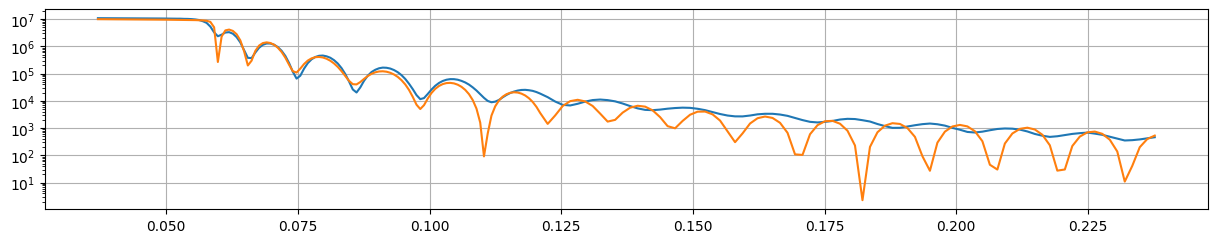

In [13]:
ans_d, ans_r_rho, ans_i_rho, ans_delta_q, ans_I, ans_Ibkg, loss, rel_losses3 = adamw(q3, ans_delta_q, r3, objective_function_weightless.objective_function,
                                                                      initial_sigma1, initial_sigma2,
                                                                      ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg,
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.001, max_iter = 1200, k=4)

In [14]:
rel_losses2 = list(map(lambda x: x * rel_losses1[-1],  rel_losses2))
rel_losses3 = list(map(lambda x: x * rel_losses2[-1],  rel_losses3))
rel_losses = rel_losses1 + rel_losses2 + rel_losses3

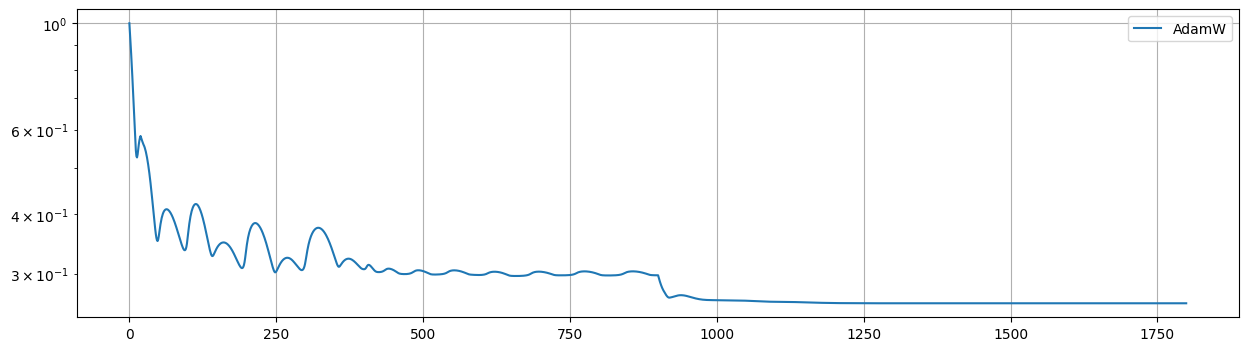

In [15]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [16]:
ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss

(tensor([405.3384,  88.1580, 100.0000,  80.7683]),
 tensor([66.4100, 17.0700]),
 tensor([-1.3931, -0.8702]),
 tensor(10719948.9000, dtype=torch.float64),
 tensor(1.1000, dtype=torch.float64),
 42.338666942457195)

In [17]:
from add_roughness import *
matrix = torch.cat(
    (
        matr[0, :].unsqueeze(0), 
        torch.cat(
            (ans_d.reshape(-1, 2), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), 
            dim=1
        )[:, torch.tensor([0, 2, 1])]
    ), dim=0
)
q_np = q.clone().detach().cpu().numpy()
fig = plot_density_profile(transform_array(matrix, len(q_np)))
fig.show()